# Meteorological normalisation and model validation

This notebook fits one random forest per monitoring station and builds the inputs needed for the later analysis. It reports station coverage, leave-one-year-out validation, wind-response diagnostics, meteorologically normalised series and a treatment-leakage check.

All stations use the same model settings. Attribution and mechanism stations are normalised in the same way; their later analytical roles do not affect model fitting.

This notebook validates and constructs the series. It does not estimate the final cross-city effect or the Paris cutoff comparison.

The full run is computationally demanding, so the slow stages save intermediate files in `data/interim/`. Restarting the kernel does not rebuild those files. A cached result should be deleted before rerunning if its inputs, model settings or construction code have changed.

## References

**Method**
- Grange, S.K., Carslaw, D.C., Lewis, A.C., Boleti, E. and Hueglin, C. (2018). Random forest meteorological normalisation models for Swiss PM10 trend analysis. Atmospheric Chemistry and Physics 18, 6223-6239. https://doi.org/10.5194/acp-18-6223-2018 (random forest normalisation for particulate trends and the general feature structure)
- Grange, S.K. and Carslaw, D.C. (2019). Using meteorological normalisation to detect interventions in air quality time series. Science of the Total Environment 653, 578-588. https://doi.org/10.1016/j.scitotenv.2018.10.344. Open accepted manuscript: https://eprints.whiterose.ac.uk/id/eprint/138077/1/meteorological_normalisation_article_markup.pdf (300 normalisation predictions, minimum node size five and the 50-model stability exercise)
- The workflow is also informed by S.K. Grange's `rmweather` package: https://github.com/skgrange/rmweather. The Python models and normalisation routine below are independent implementations. In particular, the same-month meteorological donor pools, stagnation feature and validation gates are project-specific rather than copied from `rmweather`.
- Random forests: Breiman, L. (2001). Random forests. Machine Learning 45, 5-32. https://doi.org/10.1023/A:1010933404324
- Partial dependence: Friedman, J.H. (2001). Greedy function approximation: a gradient boosting machine. Annals of Statistics 29, 1189-1232. https://doi.org/10.1214/aos/1013203451 (the wind sweeps in section 6 are related diagnostics, not standard partial-dependence curves)
- Blocked cross validation: Roberts, D.R. et al. (2017). Cross-validation strategies for data with temporal, spatial, hierarchical, or phylogenetic structure. Ecography 40, 913-929. https://doi.org/10.1111/ecog.02881 (section 5; holding out complete years avoids the neighbouring-hour leakage of a random split)
- Stagnation concept: Wang, J.X.L. and Angell, J.K. (1999). Air stagnation climatology for the United States, 1948-1998. NOAA/Air Resources Laboratory Atlas No. 1: https://repository.library.noaa.gov/view/noaa/50572. Horton, D.E., Skinner, C.B., Singh, D. and Diffenbaugh, N.S. (2014). Occurrence and persistence of future atmospheric stagnation events. Nature Climate Change 4, 698-703. https://doi.org/10.1038/nclimate2272. Their daily index uses surface wind, upper-air wind and precipitation. The hourly low-wind run used here is a simpler project feature, not that formal index.

**Leakage diagnostic**
- Driscoll, J.C. and Kraay, A.C. (1998). Consistent covariance matrix estimation with spatially dependent panel data. Review of Economics and Statistics 80(4), 549-560. https://doi.org/10.1162/003465398557825
- Hoechle, D. (2007). Robust standard errors for panel regressions with cross-sectional dependence. Stata Journal 7(3), 281-312. Open copy: https://ageconsearch.umn.edu/record/119278/files/sjart_st0128.pdf
- Newey, W.K. and West, K.D. (1987). A simple, positive semi-definite, heteroskedasticity and autocorrelation consistent covariance matrix. Econometrica 55(3), 703-708. https://doi.org/10.2307/1913610 (station-level HAC covariance in section 10)

**Data**
- Geod'Air, national air quality reference database (INERIS/LCSQA): https://www.geodair.fr/a-propos. Rows with the source quality flag `validité == 1` are retained.
- ERA5 reanalysis: Hersbach, H. et al. (2020). The ERA5 global reanalysis. Quarterly Journal of the Royal Meteorological Society 146, 1999-2049. https://doi.org/10.1002/qj.3803. ERA5 hourly single levels: https://doi.org/10.24381/cds.adbb2d47. Contains modified Copernicus Climate Change Service information; neither the European Commission nor ECMWF is responsible for any use of this information.

**Policy dates used in section 10**
- Paris restrictions: Crit'Air 5 from 1 July 2017 and Crit'Air 4 from 1 July 2019. Ville de Paris, arrêté 2019 P 15655: https://www.api-site.paris.fr/paris/public/2019%2F5%2FZonedecirculationrestreinteparisArr%C3%AAt%C3%A92019P15655.pdf
- Lyon: Crit'Air 5 and unclassified private cars restricted from 1 September 2022. Métropole de Lyon: https://www.grandlyon.com/actualite/qualite-de-lair-la-metropole-poursuit-le-deploiement-de-la-zone-a-faibles-emissions
- Marseille: the first Crit'Air restriction covering private cars began on 1 September 2022. Métropole Aix-Marseille-Provence: https://deliberations.ampmetropole.fr/documents/metropole/deliberations/2022/06/30/DECISION/24533.pdf

**Data conventions**
- The 75 percent station-month capture threshold adapts the EEA annual station-validity convention to monthly resolution. This monthly application is a project choice: https://www.eea.europa.eu/en/analysis/indicators/exceedance-of-air-quality-standards
- Negative readings marked valid by Geod'Air are retained. Jiang, N. et al. (2023). On thresholds for controlling negative particle (PM2.5) readings in air quality reporting. Environmental Monitoring and Assessment 195(10), 1187. https://doi.org/10.1007/s10661-023-11750-4. Retaining small valid values within instrument uncertainty avoids pushing low averages upwards.

**Code provenance**
- Random forests are fitted with `sklearn.ensemble.RandomForestRegressor`: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
- The published `rmweather` normalisation function is useful for comparison with the project-specific Python routine: https://github.com/skgrange/rmweather/blob/master/R/rmw_normalise.R
- The pooled Driscoll-Kraay calculation uses `linearmodels.PanelOLS`: https://bashtage.github.io/linearmodels/panel/panel/linearmodels.panel.model.PanelOLS.fit.html
- The station-level HAC calculation uses `statsmodels` OLS with robust covariance: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLSResults.get_robustcov_results.html
- The monthly-stratified meteorological draws, coherent wind sweep, screening rules and packaging code are project-specific Python routines written with NumPy and pandas. The papers motivate the analysis but are not the source of this Python code.

**Software**
- scikit-learn: Pedregosa, F. et al. (2011). Scikit-learn: machine learning in Python. Journal of Machine Learning Research 12, 2825-2830.
- linearmodels: Sheppard, K. linearmodels, estimation of linear panel models (Python package), used for PanelOLS with kernel (Driscoll-Kraay) covariance.
- statsmodels: Seabold, S. and Perktold, J. (2010). statsmodels: econometric and statistical modeling with Python. Proceedings of the 9th Python in Science Conference, 92-96.
- xarray: Hoyer, S. and Hamman, J. (2017). xarray: N-D labeled arrays and datasets in Python. Journal of Open Research Software 5(1), 10.
- pandas: McKinney, W. (2010). Data structures for statistical computing in Python. Proceedings of the 9th Python in Science Conference, 56-61.
- numpy: Harris, C.R. et al. (2020). Array programming with NumPy. Nature 585, 357-362.
- scipy: Virtanen, P. et al. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. Nature Methods 17, 261-272.
- matplotlib: Hunter, J.D. (2007). Matplotlib: a 2D graphics environment. Computing in Science and Engineering 9(3), 90-95.


## 1. Parameters

The model settings and diagnostic thresholds are collected here so they are visible before the results. The design follows Grange et al. for the random forest and sampling-and-prediction workflow, but it is not an exact reproduction.

Grange and Carslaw used 300 trees, a minimum node size of five, three candidate variables per split and 300 normalisation predictions in their 2019 intervention examples. This notebook keeps the minimum leaf size, effectively considers three of its ten features per split, and uses 300 draws. It uses 500 trees as a project choice to reduce variation from the fitted forest. The exact predictor set also differs because the available ERA5 inputs do not include the papers' synoptic types or back trajectories.

The fit margins, wind-grid rule, stagnation cap and leakage lags are screening choices for this project. They are explained where they are used and should not be presented as thresholds taken from the papers.

`n_jobs` only sets how many cores build the trees. With the seed fixed the result is the same either way.

In [1]:
import io
import os
import pickle
import time

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

os.makedirs("data/interim", exist_ok=True)

N_TREES     = 500      # project choice; the cited studies used 300
MIN_LEAF    = 5        # matches the 2019 intervention examples
MAX_FEAT    = 0.33     # 3 of the 10 features at each split
SEED        = 42
N_DRAWS     = 300      # matches Grange and Carslaw 2019
LSM_MIN     = 0.5      # majority-land rule for an ERA5 cell
STAG_MS     = 3.0      # hourly low-wind threshold, project approximation
STAG_CAP    = 120      # five-day cap, project choice
CAPTURE     = 0.75     # minimum share of a month's expected hours
CV_MIN_TEST = 200      # smallest held-out year used for a fold metric
CV_MIN_TRAIN = 2000    # smallest training set used for a fold

GRID_STEP   = 1.0
TEST_MAX    = 6
TOL_FRAC    = 0.05
GATE_R2_GAP = 0.15
REF_ATTRIB  = 0.433
REF_TRAFFIC = 0.557
GUARD_ATTRIB = REF_ATTRIB / 2
GUARD_TRAFFIC = REF_TRAFFIC / 2
EARLIER_FAILURES = ["FR20062", "FR20017", "FR20046",
                    "FR03043", "FR03014", "FR03006"]

LEAK_ALPHA  = 0.05
DK_BANDWIDTH = 18
HAC_LAGS    = 12
ZONE_TOL    = 0.10
ZONE_MIN_HOURS = 8760
GEN_REFITS  = 50

RF = dict(n_estimators=N_TREES, min_samples_leaf=MIN_LEAF,
          max_features=MAX_FEAT, random_state=SEED, n_jobs=-1)

MET_FEATURES  = ["wind_speed", "u_mean", "v_mean", "t2m", "blh", "stagnation"]
TIME_FEATURES = ["date_index", "day_of_year", "weekday", "hour"]
FEATURES      = MET_FEATURES + TIME_FEATURES

WINDOW_START = pd.Timestamp("2013-01-01")
WINDOW_END   = pd.Timestamp("2025-12-31 23:59:59")

def fit_random_forest(tab, features=FEATURES):
    return RandomForestRegressor(**RF).fit(tab[features], tab["pm25"])

## 2. Land sea mask

One cell set per city is used for every meteorological variable. A mask value of 0.5 or more means that at least half of the ERA5 cell is land, so this is used as a simple majority-land rule. It is a project choice rather than a threshold taken from the normalisation papers. Printing every cell shows that the rule was applied consistently.

Paris and Lyon have no borderline cells. Marseille is the case where the rule matters because several cells in the southern part of the box are predominantly sea. The printed values make the inclusion decision reproducible.

In [2]:
BOXES = {"paris":     [48.99, 2.21, 48.74, 2.51],
         "lyon":      [45.88, 4.72, 45.62, 5.02],
         "marseille": [43.55, 5.20, 43.20, 5.55]}

CELLS = {}
print(f"Keeping ERA5 cells with lsm >= {LSM_MIN}\n")
for city in BOXES:
    ds = xr.open_dataset(f"data/raw/era5/era5_{city}_lsm.nc")
    lsm = ds["lsm"]
    for dim in ("valid_time", "time"):
        if dim in lsm.dims:
            lsm = lsm.isel({dim: 0})
    keep = []
    print(f"{city.upper()}  box {BOXES[city]}")
    for la in lsm["latitude"].values:
        for lo in lsm["longitude"].values:
            v = float(lsm.sel(latitude=la, longitude=lo))
            print(f"  ({la:.2f}, {lo:.2f})  lsm {v:.6f}  {'keep' if v >= LSM_MIN else 'drop'}")
            if v >= LSM_MIN:
                keep.append((float(la), float(lo)))
    ds.close()
    CELLS[city] = keep
    print(f"  {len(keep)} cells kept\n")

Keeping ERA5 cells with lsm >= 0.5

PARIS  box [48.99, 2.21, 48.74, 2.51]
  (48.75, 2.25)  lsm 0.995579  keep
  (48.75, 2.50)  lsm 0.996330  keep
  2 cells kept

LYON  box [45.88, 4.72, 45.62, 5.02]
  (45.75, 4.75)  lsm 0.984037  keep
  (45.75, 5.00)  lsm 0.983310  keep
  2 cells kept

MARSEILLE  box [43.55, 5.2, 43.2, 5.55]
  (43.50, 5.25)  lsm 0.789315  keep
  (43.50, 5.50)  lsm 0.900614  keep
  (43.25, 5.25)  lsm 0.295802  drop
  (43.25, 5.50)  lsm 0.499995  drop
  2 cells kept



## 3. Meteorological features

Wind speed is computed cell by cell and then averaged, not taken as the hypotenuse of the averaged components, which would understate speed when direction varies across cells. Direction enters as the averaged u and v components rather than a bearing, which would wrap at north.

Stagnation is the number of consecutive hours below 3 m/s ending at each timestamp, capped at five days. Published stagnation indices also use upper-air wind and precipitation, so this is only a project-specific low-wind persistence feature. It adds information about prolonged calm conditions because the synoptic and back-trajectory variables used by Grange et al. are not available here. The cap prevents an unusually long calm spell from dominating the scale of the feature.

Each city is cached after the first build.

In [3]:
def city_met(city):
    required = [f"data/raw/era5/era5_{city}_{tag}_{year}.nc"
                for tag in ("wind_u", "wind_v", "t2m", "blh")
                for year in range(2013, 2026)]
    missing = [path for path in required if not os.path.exists(path)]
    if missing:
        raise FileNotFoundError(f"{city}: missing ERA5 files: {missing}")

    cached = f"data/interim/met_{city}.pkl"
    if os.path.exists(cached):
        return pd.read_pickle(cached)

    keep = CELLS[city]
    cols = {}
    for var, tag in [("u10","wind_u"), ("v10","wind_v"), ("t2m","t2m"), ("blh","blh")]:
        years = []
        for y in range(2013, 2026):
            path = f"data/raw/era5/era5_{city}_{tag}_{y}.nc"
            ds = xr.open_dataset(path)
            cells = xr.concat([ds[var].sel(latitude=la, longitude=lo, method="nearest")
                               for la, lo in keep], dim="cell")
            years.append(cells.mean(dim="cell").to_series())
            ds.close()
        cols[var] = pd.concat(years).sort_index()

    speeds = []
    for y in range(2013, 2026):
        fu = f"data/raw/era5/era5_{city}_wind_u_{y}.nc"
        fv = f"data/raw/era5/era5_{city}_wind_v_{y}.nc"
        du, dv = xr.open_dataset(fu), xr.open_dataset(fv)
        u = xr.concat([du["u10"].sel(latitude=la, longitude=lo, method="nearest")
                       for la, lo in keep], dim="cell")
        v = xr.concat([dv["v10"].sel(latitude=la, longitude=lo, method="nearest")
                       for la, lo in keep], dim="cell")
        speeds.append(np.hypot(u, v).mean(dim="cell").to_series())
        du.close()
        dv.close()

    met = pd.DataFrame({"wind_speed": pd.concat(speeds).sort_index(),
                        "u_mean": cols["u10"], "v_mean": cols["v10"],
                        "t2m": cols["t2m"], "blh": cols["blh"]})
    if met.index.duplicated().any():
        raise ValueError(f"{city}: duplicate ERA5 timestamps")
    met = met.sort_index()
    met.index.name = "datetime"

    calm = (met["wind_speed"] < STAG_MS).values
    run, streak = np.zeros(len(calm)), 0
    for i, c in enumerate(calm):
        streak = streak + 1 if c else 0
        run[i] = min(streak, STAG_CAP)
    met["stagnation"] = run

    met["date_index"]  = (met.index - pd.Timestamp("2013-01-01")).days
    met["day_of_year"] = met.index.dayofyear
    met["weekday"]     = met.index.weekday
    met["hour"]        = met.index.hour

    met = met.dropna()
    met.to_pickle(cached)
    return met

MET = {}
for city in BOXES:
    start = time.time()
    MET[city] = city_met(city)
    outside = ((MET[city].index < WINDOW_START)
               | (MET[city].index > WINDOW_END))
    if outside.any():
        raise ValueError(f"{city}: meteorology outside 2013-2025")
    print(f"{city}: {len(MET[city])} hours, "
          f"{MET[city].index.min().date()} to {MET[city].index.max().date()} "
          f"({time.time()-start:.0f}s)")
    print(MET[city][["wind_speed","t2m","blh","stagnation"]].describe().round(2).to_string())
    print()

paris: 113952 hours, 2013-01-01 to 2025-12-31 (0s)
       wind_speed        t2m        blh  stagnation
count   113952.00  113952.00  113952.00   113952.00
mean         3.54     285.37     590.37        8.63
std          1.77       7.17     477.00       17.18
min          0.07     263.92       9.83        0.00
25%          2.20     280.23     194.17        0.00
50%          3.23     284.92     466.34        0.00
75%          4.56     290.24     887.05        9.00
max         14.58     314.51    3977.32      120.00

lyon: 113952 hours, 2013-01-01 to 2025-12-31 (0s)
       wind_speed        t2m        blh  stagnation
count   113952.00  113952.00  113952.00   113952.00
mean         2.71     286.14     529.91       18.02
std          1.65       8.10     494.05       26.81
min          0.06     262.28      10.67        0.00
25%          1.46     280.09     111.41        0.00
50%          2.32     285.71     396.26        6.00
75%          3.69     291.73     805.13       25.00
max         12

## 4. Concentrations and station tables

Hourly PM2.5 rows that Geod'Air flags as valid are kept, including valid negative readings, and dates are parsed using the two formats present in the exports. The loader accepts either one explicitly named hourly file for every year from 2013 to 2025 or one explicitly named combined 2013-2025 hourly file. It does not use a broad filename search, which avoids accidentally including an annual summary or unrelated export. Each station is then joined to its own city's meteorology.

Both tiers are fitted. Normalisation is a measurement step applied station by station, so it does not depend on what the station is later used for.

Station spans are part of the validation package.

In [4]:
def read_geodair(path):
    lines = []
    with open(path, encoding="utf-8-sig") as source:
        raw_lines = source.read().splitlines()
    for line in raw_lines:
        if not line:
            continue
        if line.startswith('"') and line.endswith('"'):
            line = line[1:-1]
        lines.append(line.replace('""', '"'))
    df = pd.read_csv(io.StringIO("\n".join(lines)), sep=";", quotechar='"', engine="python")
    df.columns = [c.strip().strip('"') for c in df.columns]
    return df

def parse_dates(col):
    col = col.astype(str)
    out = pd.Series(pd.NaT, index=col.index, dtype="datetime64[ns]")
    slash = col.str.contains("/", na=False)
    out[slash]  = pd.to_datetime(col[slash],  format="%Y/%m/%d %H:%M:%S", errors="coerce")
    out[~slash] = pd.to_datetime(col[~slash], format="%Y-%m-%d %H:%M:%S", errors="coerce")
    if out.isna().any():
        raise ValueError(f"{out.isna().sum()} timestamps did not parse")
    return out

def city_pm(folder, token):
    yearly = [os.path.join(folder, f"pm2.5_{token}_{year}_hourly.csv")
              for year in range(2013, 2026)]
    combined = os.path.join(folder, f"pm2.5_{token}_2013_2025_hourly.csv")
    present = [os.path.exists(path) for path in yearly]

    if all(present):
        files = yearly
    elif not any(present) and os.path.exists(combined):
        files = [combined]
    else:
        missing = [path for path, exists in zip(yearly, present) if not exists]
        raise FileNotFoundError(
            f"{token}: expected the complete yearly set or {combined}; "
            f"missing yearly files: {missing}"
        )
    d = pd.concat([read_geodair(f) for f in files], ignore_index=True)
    d["validité"] = pd.to_numeric(d["validité"], errors="coerce")
    d = d[d["validité"] == 1].copy()
    d["valeur brute"] = pd.to_numeric(d["valeur brute"], errors="coerce")
    d = d.dropna(subset=["valeur brute"])
    d["datetime"] = parse_dates(d["Date de début"])
    outside = ~d["datetime"].between(WINDOW_START, WINDOW_END)
    if outside.any():
        raise ValueError(f"{token}: {int(outside.sum())} rows outside 2013-2025")
    return d

PM = {"paris":     city_pm("Donnee_pm2.5_paris/Donnees_hourly_yearly", "paris"),
      "lyon":      city_pm("Donnee_pm2.5_lyon", "lyon"),
      "marseille": city_pm("Donnee_pm2.5_marseille", "marseille")}

STATIONS = {"FR04143": ("paris","attribution"), "FR04055": ("paris","attribution"),
            "FR04004": ("paris","attribution"), "FR04131": ("paris","attribution"),
            "FR20062": ("lyon","attribution"),  "FR20017": ("lyon","attribution"),
            "FR20046": ("lyon","attribution"),
            "FR03043": ("marseille","attribution"), "FR03014": ("marseille","attribution"),
            "FR04329": ("paris","mechanism"),   "FR03006": ("marseille","mechanism")}

TABLES, spans = {}, []
for st, (city, tier) in STATIONS.items():
    series = (PM[city][PM[city]["code site"] == st]
                .set_index("datetime")["valeur brute"].rename("pm25"))
    if series.index.duplicated().any():
        raise ValueError(f"{st}: duplicate concentration timestamps")
    tab = MET[city].join(series, how="inner").dropna(subset=["pm25"] + FEATURES)
    TABLES[st] = tab
    spans.append({"station": st, "city": city, "tier": tier, "rows": len(tab),
                  "first": tab.index.min().date(), "last": tab.index.max().date(),
                  "years": tab.index.year.nunique()})

spans = pd.DataFrame(spans)
print(spans.to_string(index=False))

station      city        tier   rows      first       last  years
FR04143     paris attribution  55370 2013-01-01 2019-09-22      7
FR04055     paris attribution  51403 2019-09-30 2025-12-31      7
FR04004     paris attribution  32516 2022-01-01 2025-12-31      4
FR04131     paris attribution  34307 2022-01-01 2025-12-31      4
FR20062      lyon attribution 110425 2013-01-01 2025-12-31     13
FR20017      lyon attribution  47594 2020-05-12 2025-12-31      6
FR20046      lyon attribution  98270 2013-01-01 2025-12-31     13
FR03043 marseille attribution 106646 2013-01-02 2025-12-31     13
FR03014 marseille attribution  51062 2020-01-08 2025-12-31      6
FR04329     paris   mechanism 110724 2013-01-01 2025-12-31     13
FR03006 marseille   mechanism 104377 2013-01-01 2025-12-31     13


## 5. Leave one year out cross validation

One forest per station per held out year. Whole years are held out because random splits let neighbouring hours appear in both training and test, which inflates the apparent fit.

Pooled held-out R-squared and RMSE are reported for each station. The first and last folds are also shown separately because the date-index feature must extrapolate in those folds, whereas the middle folds interpolate. Their performance therefore needs to be interpreted separately.

Stations have different numbers of years available, so fold counts differ. A fold is only scored when the held-out year has at least 200 observations and the remaining years provide at least 2,000 training observations. These are project-specific safeguards, equal to about eight and 83 complete days respectively, rather than published model thresholds.

In [5]:
def cross_validate(tab):
    folds, held = [], []
    for year in sorted(tab.index.year.unique()):
        train = tab[tab.index.year != year]
        test  = tab[tab.index.year == year]
        if len(test) < CV_MIN_TEST or len(train) < CV_MIN_TRAIN:
            folds.append({"year": year, "n": len(test), "r2": np.nan, "rmse": np.nan})
            continue
        model = fit_random_forest(train)
        pred = model.predict(test[FEATURES])
        folds.append({"year": year, "n": len(test),
                      "r2": r2_score(test["pm25"], pred),
                      "rmse": float(np.sqrt(mean_squared_error(test["pm25"], pred)))})
        held.append(pd.DataFrame({"obs": test["pm25"].values, "pred": pred}))
    folds = pd.DataFrame(folds)
    held = pd.concat(held)
    return folds, {"r2": r2_score(held["obs"], held["pred"]),
                   "rmse": float(np.sqrt(mean_squared_error(held["obs"], held["pred"]))),
                   "folds": int(folds["r2"].notna().sum())}

CV = {}
for st, tab in TABLES.items():
    cached = f"data/interim/cv_{st}.pkl"
    if os.path.exists(cached):
        with open(cached, "rb") as source:
            CV[st] = pickle.load(source)
    else:
        start = time.time()
        CV[st] = cross_validate(tab)
        with open(cached, "wb") as destination:
            pickle.dump(CV[st], destination)
        print(f"{st}: {CV[st][1]['folds']} folds, {time.time()-start:.0f}s")

rows = []
for st, (folds, pooled) in CV.items():
    done = folds[folds["r2"].notna()]
    rows.append({"station": st, "city": STATIONS[st][0], "tier": STATIONS[st][1],
                 "folds": pooled["folds"],
                 "pooled_R2": round(pooled["r2"], 3),
                 "pooled_RMSE": round(pooled["rmse"], 2),
                 "first_fold": f"{int(done.iloc[0].year)}: {done.iloc[0].r2:.3f}",
                 "last_fold":  f"{int(done.iloc[-1].year)}: {done.iloc[-1].r2:.3f}"})
CV_TABLE = pd.DataFrame(rows)
print(CV_TABLE.to_string(index=False))

print("\nPer fold:")
for st, (folds, _) in CV.items():
    print(f"\n{st}")
    print(folds.round(3).to_string(index=False))

station      city        tier  folds  pooled_R2  pooled_RMSE  first_fold   last_fold
FR04143     paris attribution      7      0.431         8.45 2013: 0.421 2019: 0.432
FR04055     paris attribution      7      0.438         6.07 2019: 0.612 2025: 0.395
FR04004     paris attribution      4      0.373         6.49 2022: 0.215 2025: 0.431
FR04131     paris attribution      4      0.358         5.27 2022: 0.347 2025: 0.341
FR20062      lyon attribution     13      0.494         7.96 2013: 0.437 2025: 0.487
FR20017      lyon attribution      6      0.470         6.87 2020: 0.367 2025: 0.416
FR20046      lyon attribution     12      0.467         8.34 2013: 0.452 2025: 0.346
FR03043 marseille attribution     13      0.447         6.35 2013: 0.374 2025: 0.308
FR03014 marseille attribution      6      0.345         5.89 2020: 0.308 2025: 0.113
FR04329     paris   mechanism     13      0.557         7.70 2013: 0.523 2025: 0.461
FR03006 marseille   mechanism     13      0.520         6.66 2013

## 6. Wind-response diagnostic

This diagnostic checks whether the fitted concentration generally falls as wind speed rises. Wind speed cannot be varied on its own because the `u` and `v` components determine its magnitude, while the stagnation feature also depends on the wind threshold. Holding those variables fixed would give the model combinations that cannot occur.

For each grid value, the code therefore rescales the two wind components to the new speed. Stagnation is set to zero at or above 3 m/s and otherwise continues the run ending in the previous hour, capped at 120 hours. Records with exactly zero observed wind are excluded because their components cannot be rescaled; the number excluded is printed.

The assessment covers 0 to 6 m/s. It requires a positive total decline and no upward one-metre step larger than 5% of that decline. The range, one-metre grid and 5% allowance are project screening choices. They are intended to flag a clearly implausible fitted response, not to impose a published physical law. Values from 6 to 8 m/s are displayed but do not enter the decision. A 0.5 m/s grid is reported as a sensitivity check rather than a second decision rule, because the step-based criterion changes mechanically with grid spacing.

The stagnation substitution changes at exactly 3 m/s, so these curves are model diagnostics rather than uncomplicated physical partial-dependence curves. Section 9 examines how much that constructed discontinuity contributed to the earlier one-variable sweep.

Wind-response check, tested region 0 to 6; s6 and s7 are descriptive
station      city  excluded     P0     P6  decline  max_step_s0_s5  tolerance      s6      s7 wind_gate
FR04143     paris         0 18.145 14.314    3.831          0.1537     0.1916 -0.3040 -0.2280      PASS
FR04055     paris         0 13.103 10.093    3.010         -0.1119     0.1505 -0.2486 -0.2151      PASS
FR04004     paris         0 12.175  8.961    3.213         -0.1334     0.1607 -0.1245 -0.0674      PASS
FR04131     paris         0 11.327  8.599    2.728         -0.0674     0.1364 -0.4307 -0.1630      PASS
FR20062      lyon         0 14.065 10.644    3.421         -0.1965     0.1710  0.1312  0.0603      PASS
FR20017      lyon         0 11.485  8.404    3.081         -0.0119     0.1541  0.0417  0.0160      PASS
FR20046      lyon         0 12.055  9.621    2.433         -0.1087     0.1217  0.1602  0.0491      PASS
FR03043 marseille         0 12.545  9.203    3.341         -0.1706     0.1671  0.1152  0.1019      

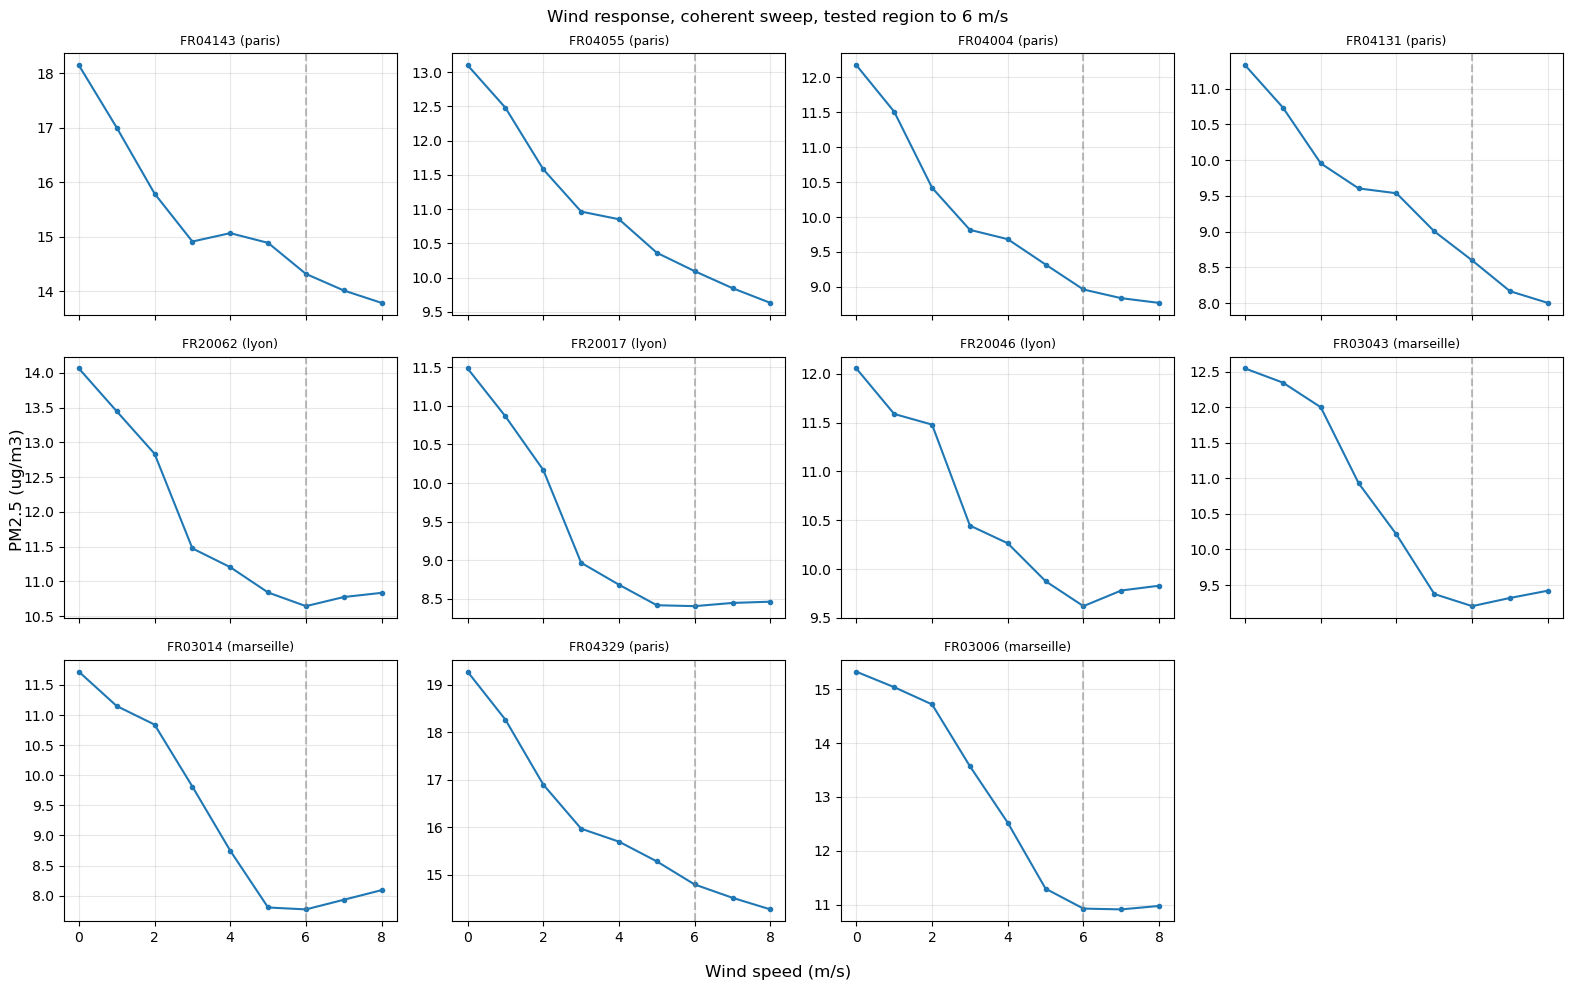


Sensitivity, 0.5 m/s grid, not gating:
  FR04143: decline +3.831, max step +0.1314, tolerance 0.1916, PASS
  FR04055: decline +3.010, max step -0.0150, tolerance 0.1505, PASS
  FR04004: decline +3.213, max step -0.0317, tolerance 0.1607, PASS
  FR04131: decline +2.728, max step -0.0014, tolerance 0.1364, PASS
  FR20062: decline +3.421, max step +0.1204, tolerance 0.1710, PASS
  FR20017: decline +3.081, max step +0.0146, tolerance 0.1541, PASS
  FR20046: decline +2.433, max step +0.1767, tolerance 0.1217, FAIL
  FR03043: decline +3.341, max step -0.0089, tolerance 0.1671, PASS
  FR03014: decline +3.948, max step +0.0260, tolerance 0.1974, PASS
  FR04329: decline +4.472, max step -0.0834, tolerance 0.2236, PASS
  FR03006: decline +4.397, max step -0.0490, tolerance 0.2198, PASS


In [6]:
# Stagnation run ending at the previous HOUR, taken from the complete met series.
# Shifting the pm25-merged table would step back to the previous surviving row,
# which after a concentration gap is not the previous hour.
PREV_RUN = {city: MET[city]["stagnation"].shift(1).fillna(0) for city in MET}

def coherent_sweep(tab, model, prev_run_full, step=GRID_STEP):
    speed = tab["wind_speed"].values
    keep = speed > 0
    excluded = int((~keep).sum())
    base = tab[keep]
    observed = speed[keep]
    prev_run = prev_run_full.reindex(tab.index).values[keep]
    grid = np.arange(0, 8 + step/2, step)
    X = base[FEATURES].copy()
    P = []
    for w in grid:
        scale = w / observed
        X["wind_speed"] = w
        X["u_mean"] = base["u_mean"].values * scale
        X["v_mean"] = base["v_mean"].values * scale
        X["stagnation"] = 0.0 if w >= STAG_MS else np.minimum(prev_run + 1, STAG_CAP)
        P.append(float(model.predict(X).mean()))
    return grid, np.array(P), excluded

MODELS = {st: fit_random_forest(t)
          for st, t in TABLES.items()}

SWEEP, rows, curves = {}, [], []
for st, tab in TABLES.items():
    for step in (1.0, 0.5):
        SWEEP[(st, step)] = coherent_sweep(tab, MODELS[st],
                                           PREV_RUN[STATIONS[st][0]], step)
    grid, P, excluded = SWEEP[(st, 1.0)]
    steps = np.diff(P)
    tested = steps[:TEST_MAX]
    decline = P[0] - P[TEST_MAX]
    tol = TOL_FRAC * decline
    passed = bool(decline > 0 and tested.max() <= tol)
    rows.append({"station": st, "city": STATIONS[st][0], "excluded": excluded,
                 "P0": round(P[0], 3), "P6": round(P[TEST_MAX], 3),
                 "decline": round(decline, 3),
                 "max_step_s0_s5": round(float(tested.max()), 4),
                 "tolerance": round(float(tol), 4),
                 "s6": round(float(steps[6]), 4),
                 "s7": round(float(steps[7]), 4),
                 "wind_gate": "PASS" if passed else "FAIL"})
    curves.append({"station": st,
                   **{f"P({int(x)})": round(v, 3) for x, v in zip(grid, P)}})

WIND_CHECK = pd.DataFrame(rows)
print("Wind-response check, tested region 0 to 6; s6 and s7 are descriptive")
print(WIND_CHECK.to_string(index=False))
print("\nFull grid values, 1.0 m/s spacing:")
print(pd.DataFrame(curves).to_string(index=False))

fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True)
for ax, st in zip(axes.ravel(), TABLES):
    grid, P, _ = SWEEP[(st, 1.0)]
    ax.plot(grid, P, "-o", ms=3)
    ax.axvline(6, color="grey", ls="--", alpha=0.5)
    ax.set_title(f"{st} ({STATIONS[st][0]})", fontsize=9)
    ax.grid(alpha=0.3)
for ax in axes.ravel()[len(TABLES):]:
    ax.axis("off")
fig.suptitle("Wind response, coherent sweep, tested region to 6 m/s")
fig.supxlabel("Wind speed (m/s)")
fig.supylabel("PM2.5 (ug/m3)")
plt.tight_layout()
plt.show()

print("\nSensitivity, 0.5 m/s grid, not gating:")
for st in TABLES:
    grid, P, _ = SWEEP[(st, 0.5)]
    upto = grid <= TEST_MAX
    s = np.diff(P[upto])
    d = P[0] - P[upto][-1]
    print(f"  {st}: decline {d:+.3f}, max step {s.max():+.4f}, "
          f"tolerance {TOL_FRAC*d:.4f}, "
          f"{'PASS' if (d > 0 and s.max() <= TOL_FRAC*d) else 'FAIL'}")

## 7. Normalised series

Time features stay at their observed values, which allows the normalised series to retain its trend and calendar pattern. The six meteorological features are replaced by draws from the station's own record and the predictions are averaged.

Two things about the draws matter. Each draw takes all six meteorological values from a single source hour, so the drawn conditions occurred together rather than being an incoherent mixture. Draws also come from the same calendar month as the target hour, pooled across years, so summer hours are not assigned winter weather.

The published `rmweather` routine generally resamples the non-trend predictors together. Restricting the donor pool by month and resampling only the available meteorological features are choices made for this dataset. They preserve joint weather conditions while limiting unrealistic seasonal substitutions. The 300 draws follow Grange and Carslaw (2019). This is the slow stage, so the result is cached for each station.

In [7]:
def normalise(st, tab, model=None):
    cached = f"data/interim/norm_{st}.pkl"
    if os.path.exists(cached):
        return pd.read_pickle(cached)

    if model is None:
        model = fit_random_forest(tab)
    rng = np.random.default_rng(SEED)
    by_month = {m: np.where(tab.index.month == m)[0] for m in range(1, 13)}
    met_vals, time_vals = tab[MET_FEATURES].values, tab[TIME_FEATURES].values

    total = np.zeros(len(tab))
    for _ in range(N_DRAWS):
        pick = np.empty(len(tab), dtype=int)
        for rows_m in by_month.values():
            if len(rows_m):
                pick[rows_m] = rng.choice(rows_m, size=len(rows_m), replace=True)
        drawn = pd.DataFrame(np.column_stack([met_vals[pick], time_vals]),
                             columns=MET_FEATURES + TIME_FEATURES)[FEATURES]
        total += model.predict(drawn)

    out = tab.copy()
    out["pm25_norm"] = total / N_DRAWS
    out.to_pickle(cached)
    return out

NORM = {}
for st, tab in TABLES.items():
    start = time.time()
    NORM[st] = normalise(st, tab, MODELS[st])
    print(f"{st}: raw {NORM[st]['pm25'].mean():.2f}, "
          f"normalised {NORM[st]['pm25_norm'].mean():.2f} ({time.time()-start:.0f}s)")

def monthly(df, col):
    d = df.copy()
    d["ym"] = d.index.to_period("M")
    g = d.groupby("ym")[col].agg(["mean", "count"])
    g["hours"] = g.index.to_timestamp().to_series().dt.days_in_month.values * 24
    g = g[g["count"] / g["hours"] >= CAPTURE]
    if not (g["mean"] > 0).all():
        raise ValueError(f"non-positive monthly mean in {col}")
    return g["mean"]

MONTHLY = {st: pd.DataFrame({"observed":   monthly(NORM[st], "pm25"),
                             "normalised": monthly(NORM[st], "pm25_norm")}).dropna()
           for st in NORM}
print("\nStation months after the capture rule:")
print(pd.Series({st: len(m) for st, m in MONTHLY.items()}).to_string())

FR04143: raw 15.08, normalised 14.96 (0s)
FR04055: raw 11.12, normalised 11.11 (0s)
FR04004: raw 9.98, normalised 9.93 (0s)
FR04131: raw 9.58, normalised 9.53 (0s)
FR20062: raw 12.95, normalised 13.03 (0s)
FR20017: raw 10.27, normalised 10.35 (0s)
FR20046: raw 11.30, normalised 11.39 (0s)
FR03043: raw 11.32, normalised 11.48 (0s)
FR03014: raw 9.95, normalised 10.14 (0s)
FR04329: raw 15.98, normalised 15.95 (0s)
FR03006: raw 13.69, normalised 13.88 (0s)

Station months after the capture rule:
FR04143     78
FR04055     69
FR04004     45
FR04131     48
FR20062    154
FR20017     64
FR20046    136
FR03043    150
FR03014     71
FR04329    156
FR03006    142


## 8. Gate, fit branch and consolidated result

The fit branch has two parts.

The relative condition is one-sided and tier-specific. A station fails only if its cross-validated R-squared is more than 0.15 below its tier reference. Attribution stations use 0.433, the rounded mean of the seven Paris and Lyon attribution results used to set the benchmark. Mechanism stations use 0.557, the FR04329 result used as their benchmark. The fixed values are printed beside the attribution mean recomputed from this run.

The absolute guard is half the relevant reference. A station below that guard is excluded from the later normalised analyses. The 0.15 margin and half-reference guard are project screening choices, not general random-forest performance standards. Their purpose is to stop a substantially weaker station from passing only because it is compared with a modest benchmark.

The consolidated result requires all three conditions: the relative fit check, the absolute guard and the wind-response diagnostic in section 6. Section 9 separately explains why the initial one-variable wind sweep produced a different result.

In [8]:
attribution_ref = [s for s in STATIONS
                   if STATIONS[s][1] == "attribution" and STATIONS[s][0] in ("paris", "lyon")]
print(f"Attribution reference {REF_ATTRIB} (fixed); computed now for disclosure only: "
      f"{np.mean([CV[s][1]['r2'] for s in attribution_ref]):.6f} "
      f"over {len(attribution_ref)} stations")
print(f"Traffic reference {REF_TRAFFIC} (fixed, FR04329)")
print(f"Guards: attribution {GUARD_ATTRIB:.4f}, traffic {GUARD_TRAFFIC:.4f}\n")

rows = []
for st in STATIONS:
    tier = STATIONS[st][1]
    ref, guard = ((REF_TRAFFIC, GUARD_TRAFFIC) if tier == "mechanism"
                  else (REF_ATTRIB, GUARD_ATTRIB))
    r2 = CV[st][1]["r2"]
    below = ref - r2
    rows.append({"station": st, "city": STATIONS[st][0], "tier": tier,
                 "R2": round(r2, 6), "reference": ref,
                 "below_ref_by": round(below, 4),
                 "relative": "PASS" if below <= GATE_R2_GAP else "FAIL",
                 "guard": round(guard, 4),
                 "factor": round(r2 / guard, 2),
                 "guard_result": "PASS" if r2 >= guard else "EXCLUDE",
                 "wind": WIND_CHECK.set_index("station").loc[st, "wind_gate"]})

GATE = pd.DataFrame(rows)
GATE["gate"] = np.where((GATE["relative"] == "PASS")
                        & (GATE["guard_result"] == "PASS")
                        & (GATE["wind"] == "PASS"), "PASS", "FAIL")
print(GATE.to_string(index=False))
print(f"\nMinimum guard factor across all stations: {GATE['factor'].min():.2f}")
print("Initial one-variable wind sweep flagged: "
      + ", ".join(EARLIER_FAILURES) + ".")

Attribution reference 0.433 (fixed); computed now for disclosure only: 0.432966 over 7 stations
Traffic reference 0.557 (fixed, FR04329)
Guards: attribution 0.2165, traffic 0.2785

station      city        tier       R2  reference  below_ref_by relative  guard  factor guard_result wind gate
FR04143     paris attribution 0.430759      0.433        0.0022     PASS 0.2165    1.99         PASS PASS PASS
FR04055     paris attribution 0.438028      0.433       -0.0050     PASS 0.2165    2.02         PASS PASS PASS
FR04004     paris attribution 0.373272      0.433        0.0597     PASS 0.2165    1.72         PASS PASS PASS
FR04131     paris attribution 0.358117      0.433        0.0749     PASS 0.2165    1.65         PASS PASS PASS
FR20062      lyon attribution 0.493711      0.433       -0.0607     PASS 0.2165    2.28         PASS PASS PASS
FR20017      lyon attribution 0.469855      0.433       -0.0369     PASS 0.2165    2.17         PASS PASS PASS
FR20046      lyon attribution 0.467017    

## 9. Why the initial wind sweep failed

The initial diagnostic changed wind speed while leaving its related predictors unchanged. This section checks whether the stagnation feature was mainly responsible for the resulting upward steps.

For the six stations flagged by that initial sweep, the comparison asks whether fixing stagnation at its median reduces the largest positive step among steps two to four by at least 50%. A station is testable only when the initial sweep contains a positive step; a zero baseline cannot demonstrate a reduction.

This is a diagnostic comparison rather than a physical partial-dependence curve. The `u` and `v` components remain fixed while wind speed changes, so the comparison is useful only for isolating the contribution of stagnation within the earlier construction.

In [9]:
def comparison_sweep(tab, model, freeze_stagnation, step=GRID_STEP):
    base = tab[tab["wind_speed"].values > 0]
    grid = np.arange(0, 8 + step/2, step)
    X = base[FEATURES].copy()
    if freeze_stagnation:
        X["stagnation"] = float(base["stagnation"].median())
    P = []
    for w in grid:
        X["wind_speed"] = w
        P.append(float(model.predict(X).mean()))
    return grid, np.array(P)

rows = []
for st, tab in TABLES.items():
    _, incoherent = comparison_sweep(tab, MODELS[st], False)
    _, frozen     = comparison_sweep(tab, MODELS[st], True)
    max_inc = max(0.0, float(np.diff(incoherent)[1:4].max()))
    max_frz = max(0.0, float(np.diff(frozen)[1:4].max()))
    reduction = np.nan if max_inc == 0 else round(100 * (1 - max_frz / max_inc), 1)
    is_flagged = st in EARLIER_FAILURES
    is_testable = bool(is_flagged and max_inc > 0)
    rows.append({"station": st, "earlier_fail": is_flagged,
                 "testable": is_testable,
                 "max_positive_incoherent": round(max_inc, 4),
                 "max_positive_frozen": round(max_frz, 4),
                 "reduction_pct": reduction,
                 "meets_prediction": (bool(reduction >= 50)
                                      if is_testable else None)})

CONFIRM = pd.DataFrame(rows)
print(CONFIRM.to_string(index=False))
tested = CONFIRM[CONFIRM["testable"]]
untestable = int((CONFIRM["earlier_fail"] & ~CONFIRM["testable"]).sum())
print(f"\nPrediction met at {int(tested['meets_prediction'].sum())} "
      f"of {len(tested)} testable stations; {untestable} flagged stations "
      "had no positive baseline step.")

station  earlier_fail  testable  max_positive_incoherent  max_positive_frozen  reduction_pct meets_prediction
FR04143         False     False                   0.0039               0.0766        -1864.0             None
FR04055         False     False                   0.0000               0.0190            NaN             None
FR04004         False     False                   0.0000               0.0000            NaN             None
FR04131         False     False                   0.0000               0.0044            NaN             None
FR20062          True      True                   0.1615               0.3172          -96.4            False
FR20017          True      True                   0.0059               0.0858        -1342.1            False
FR20046          True      True                   0.2012               0.3818          -89.8            False
FR03043          True     False                   0.0000               0.0000            NaN             None
FR03014   

### Interpretation

Freezing stagnation does not reduce the positive step at any testable flagged station. The three Marseille rows with zero steps in both versions are reported as untestable rather than as successful reductions. This points to the inconsistency between wind speed and the unchanged `u` and `v` components, rather than stagnation alone, as the main problem in the initial sweep. The coherent construction in section 6 resolves that inconsistency.

## 10. Treatment leakage diagnostic

The normalisation keeps a date index feature, which is what lets the normalised series carry a trend. The risk is that this feature absorbs part of the treatment effect, so the weather adjustment itself steps at the treatment date.

The diagnostic regresses the monthly adjustment, observed minus normalised, on the station's treatment indicator, with station effects and month-of-year effects. The pooled model uses Driscoll-Kraay covariance with a Bartlett kernel and an 18-month bandwidth. The station models use Newey-West covariance with 12 lags. Eighteen months extends beyond one seasonal cycle in the pooled series, while 12 lags covers one year in the station series. These bandwidths are project choices, so the test is a screening diagnostic rather than a proof that leakage is absent.

This tests one possible leakage channel: whether the fitted adjustment changes at the treatment date. It does not establish that all leakage is absent. The weather-only variant in section 12 addresses the separate concern that the time features may absorb part of the policy-related change.

The four Paris attribution stations use 1 July 2017, the date of the first private-car restriction inside Paris. FR04329 uses 1 July 2019. Lyon and Marseille use 1 September 2022.

The onset dates are stored with the results so that later notebooks can verify them when loading the package.

In [10]:
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS

# Date used for each station's first relevant private-car restriction.
# The dates are stored with the output so later notebooks can check them.
ONSET = {"FR04143": "2017-07-01", "FR04055": "2017-07-01",
         "FR04004": "2017-07-01", "FR04131": "2017-07-01",
         "FR04329": "2019-07-01",
         "FR20062": "2022-09-01", "FR20017": "2022-09-01", "FR20046": "2022-09-01",
         "FR03043": "2022-09-01", "FR03014": "2022-09-01", "FR03006": "2022-09-01"}

parts = []
for st, m in MONTHLY.items():
    d = m.copy()
    d["adjustment"]    = d["observed"] - d["normalised"]
    d["station"]       = st
    d["date"]          = d.index.to_timestamp()
    d["treated"]       = (d["date"] >= pd.Timestamp(ONSET[st])).astype(int)
    d["month_of_year"] = d["date"].dt.month
    parts.append(d.reset_index(drop=True))
ADJ = pd.concat(parts, ignore_index=True)

pooled = PanelOLS.from_formula(
    "adjustment ~ 1 + treated + C(month_of_year) + EntityEffects",
    data=ADJ.set_index(["station", "date"]), drop_absorbed=True
).fit(cov_type="kernel", kernel="bartlett", bandwidth=DK_BANDWIDTH)
coef, pval = pooled.params["treated"], pooled.pvalues["treated"]
print(f"Pooled: station effects, month-of-year effects, Driscoll-Kraay "
      f"Bartlett bandwidth {DK_BANDWIDTH}")
pooled_flag = "FLAGGED" if pval < LEAK_ALPHA else "not flagged"
print(f"  treated {coef:+.4f}, p {pval:.4f} -> {pooled_flag}\n")

rows = []
for st in MONTHLY:
    d = ADJ[ADJ["station"] == st]
    pre, post = int((d["treated"] == 0).sum()), int((d["treated"] == 1).sum())
    if d["treated"].nunique() < 2:
        rows.append({"station": st, "onset": ONSET[st],
                     "months_pre": pre, "months_post": post,
                     "coef": np.nan, "p": np.nan, "result": "not testable"})
        continue
    fit = smf.ols("adjustment ~ treated + C(month_of_year)", data=d).fit(
        cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})
    rows.append({"station": st, "onset": ONSET[st],
                 "months_pre": pre, "months_post": post,
                 "coef": round(fit.params["treated"], 4),
                 "p": round(fit.pvalues["treated"], 4),
                 "result": ("FLAGGED" if fit.pvalues["treated"] < LEAK_ALPHA
                            else "not flagged")})

LEAK = pd.DataFrame(rows)
print(f"Per station: month-of-year effects, Newey-West {HAC_LAGS} lags")
print(LEAK.to_string(index=False))

LEAK_ONSET_MARSEILLE = ONSET["FR03043"]
print(f"\nMarseille onset used: {LEAK_ONSET_MARSEILLE}")

Pooled: station effects, month-of-year effects, Driscoll-Kraay Bartlett bandwidth 18
  treated -0.3345, p 0.0806 -> not flagged

Per station: month-of-year effects, Newey-West 12 lags
station      onset  months_pre  months_post    coef      p       result
FR04143 2017-07-01          53           25 -0.6944 0.2984  not flagged
FR04055 2017-07-01           0           69     NaN    NaN not testable
FR04004 2017-07-01           0           45     NaN    NaN not testable
FR04131 2017-07-01           0           48     NaN    NaN not testable
FR20062 2022-09-01         114           40 -0.3532 0.4114  not flagged
FR20017 2022-09-01          27           37 -0.5643 0.2862  not flagged
FR20046 2022-09-01         109           27 -0.5377 0.0723  not flagged
FR03043 2022-09-01         110           40  0.0961 0.7147  not flagged
FR03014 2022-09-01          32           39  0.1098 0.7842  not flagged
FR04329 2019-07-01          78           78 -0.7452 0.0823  not flagged
FR03006 2022-09-01      

## 11. Package summary

The cell below gathers the validation results already produced in sections 2 to 10 and writes them to one package for the later notebooks.

In [11]:
print("VALIDATION PACKAGE\n")
print("Cells kept per city:", {k: len(v) for k, v in CELLS.items()})
print("\nStation spans")
print(spans.to_string(index=False))
print("\nCross validation")
print(CV_TABLE.to_string(index=False))
print("\nWind-response check")
print(WIND_CHECK.to_string(index=False))
print("\nGate, consolidated")
print(GATE.to_string(index=False))
print("\nConfirmatory diagnostic")
print(CONFIRM.to_string(index=False))
print("\nLeakage per station")
print(LEAK.to_string(index=False))
print(f"\nLeakage pooled: {coef:+.4f}, p {pval:.4f}, "
      f"Marseille onset {LEAK_ONSET_MARSEILLE}")

pd.to_pickle({"spans": spans, "cv": CV_TABLE, "wind": WIND_CHECK, "gate": GATE,
              "confirm": CONFIRM, "leak": LEAK,
              "leak_pooled": (float(coef), float(pval)),
              "leak_onset_marseille": LEAK_ONSET_MARSEILLE,
              "leak_onsets": dict(ONSET)},
             "data/interim/validation_package.pkl")
print("\nSaved to data/interim/validation_package.pkl")

VALIDATION PACKAGE

Cells kept per city: {'paris': 2, 'lyon': 2, 'marseille': 2}

Station spans
station      city        tier   rows      first       last  years
FR04143     paris attribution  55370 2013-01-01 2019-09-22      7
FR04055     paris attribution  51403 2019-09-30 2025-12-31      7
FR04004     paris attribution  32516 2022-01-01 2025-12-31      4
FR04131     paris attribution  34307 2022-01-01 2025-12-31      4
FR20062      lyon attribution 110425 2013-01-01 2025-12-31     13
FR20017      lyon attribution  47594 2020-05-12 2025-12-31      6
FR20046      lyon attribution  98270 2013-01-01 2025-12-31     13
FR03043 marseille attribution 106646 2013-01-02 2025-12-31     13
FR03014 marseille attribution  51062 2020-01-08 2025-12-31      6
FR04329     paris   mechanism 110724 2013-01-01 2025-12-31     13
FR03006 marseille   mechanism 104377 2013-01-01 2025-12-31     13

Cross validation
station      city        tier  folds  pooled_R2  pooled_RMSE  first_fold   last_fold
FR04143  

## 12. Weather-only sensitivity series

The weather model is given the date among its inputs, along with the day of year, the day of week and the hour. Those inputs are what allow the normalised series to keep a trend and a seasonal shape rather than being flattened. That is necessary, but it creates a risk: if the model uses them to fit part of what the policy did, some of the effect disappears into the normalisation before any analysis begins.

The preceding diagnostic tests whether the fitted adjustment steps at the treatment date. This section examines the broader concern by fitting a second model that receives the six meteorological features but none of the four time features. The forest settings, seed and stations are unchanged.

Because a model without time inputs cannot directly represent a trend or calendar pattern, the fitted weather component is subtracted from the observation and the station mean is added back. This residualisation formula is a project-specific sensitivity construction, not the normalisation algorithm reported in the cited papers. It keeps the station on approximately its original scale while leaving the unexplained trend and calendar structure in the series. Hourly adjusted values are not clipped; the existing monthly aggregation check still requires every retained monthly mean to be positive.

Removing every time input changes more than the date-index channel alone. It also removes the day-of-year, weekday and hour variables, so the resulting difference is a broad sensitivity check rather than a direct estimate or formal bound on leakage. Temperature and boundary-layer height may still capture some seasonal variation indirectly.

The later analysis should therefore report this result alongside the main normalised series and interpret disagreement as sensitivity to the treatment of time features.

In [12]:
# Every time feature is removed; the model sees meteorology only.
WEATHER_ONLY_FEATURES = list(MET_FEATURES)
assert not set(WEATHER_ONLY_FEATURES) & set(TIME_FEATURES)


def normalise_weather_only(st, tab):
    """Second series from a model given meteorology alone.

    With no time inputs the model cannot represent a trend or a calendar
    pattern, so the trend is whatever remains once the weather component is
    removed: the observation minus what the weather explains, with the station
    mean added back to restore the scale.
    """
    cached = f"data/interim/norm_weatheronly_unclipped_{st}.pkl"
    if os.path.exists(cached):
        return pd.read_pickle(cached)

    model = fit_random_forest(tab, WEATHER_ONLY_FEATURES)
    weather_part = model.predict(tab[WEATHER_ONLY_FEATURES])

    out = tab.copy()
    out["pm25_norm"] = (tab["pm25"].to_numpy()
                        - weather_part
                        + float(tab["pm25"].mean()))

    out.to_pickle(cached)
    return out


WO = {}
for st, tab in TABLES.items():
    start = time.time()
    WO[st] = normalise_weather_only(st, tab)
    print(f"{st}: observed {WO[st]['pm25'].mean():.2f}, "
          f"weather-only {WO[st]['pm25_norm'].mean():.2f} "
          f"({time.time()-start:.0f}s)")

check = []
for st in TABLES:
    a, b = NORM[st]["pm25_norm"], WO[st]["pm25_norm"]
    weather_only_monthly = monthly(WO[st], "pm25_norm")
    check.append({"station": st,
                  "with_time_mean": round(float(a.mean()), 3),
                  "weather_only_mean": round(float(b.mean()), 3),
                  "weather_only_months": len(weather_only_monthly),
                  "correlation": round(float(np.corrcoef(a, b)[0, 1]), 4)})
WO_TABLE = pd.DataFrame(check)
print()
print(WO_TABLE.to_string(index=False))
print(f"\n{len(WO)} stations refit on {len(WEATHER_ONLY_FEATURES)} meteorological "
      f"features with all {len(TIME_FEATURES)} time features removed.")

FR04143: observed 15.08, weather-only 15.07 (0s)
FR04055: observed 11.12, weather-only 11.12 (0s)
FR04004: observed 9.98, weather-only 9.98 (0s)
FR04131: observed 9.58, weather-only 9.58 (0s)
FR20062: observed 12.95, weather-only 12.94 (0s)
FR20017: observed 10.27, weather-only 10.27 (0s)
FR20046: observed 11.30, weather-only 11.29 (0s)
FR03043: observed 11.32, weather-only 11.31 (0s)
FR03014: observed 9.95, weather-only 9.95 (0s)
FR04329: observed 15.98, weather-only 15.97 (0s)
FR03006: observed 13.69, weather-only 13.68 (0s)

station  with_time_mean  weather_only_mean  weather_only_months  correlation
FR04143          14.961             15.066                   78       0.4580
FR04055          11.115             11.116                   69       0.3537
FR04004           9.931              9.978                   45       0.4311
FR04131           9.530              9.582                   48       0.4278
FR20062          13.032             12.942                  154       0.3904
FR20

## 13. Surrounding-area companion stations

The main Paris stations are inside the city boundary. This section separately prepares eligible background stations from the supplied Petite Couronne export, allowing a later companion analysis to examine measurements in the surrounding area.

These stations should not automatically be assigned the Paris July 2017 treatment. Their inclusion in the export and their monitoring classification do not establish that they were inside the same policy boundary or subject to the same onset date. A later analysis must define and document the relevant boundary and date before estimating an effect. This notebook only constructs the station series.

The selection rule keeps urban or suburban background stations and excludes roadside sites. It is applied to the recorded classification before coverage is examined, so it is not changed according to which stations have the longest records. This is a measurement-based selection rule, not a claim about policy membership.

Every station is then checked against the published annual statistics before it is fitted. A station whose computed annual means do not reproduce the official figures within the stated tolerance is not used, whatever its coverage.

In [13]:
ZONE_FOLDER = "Donnee_pm2.5_petitecouronne"
ZONE_YEARLY = f"{ZONE_FOLDER}/pm2.5_petitecouronne_2013_2025_yearly.csv"

if not os.path.isdir(ZONE_FOLDER):
    ZONE_DATA_PRESENT = False
    print(f"{ZONE_FOLDER} not found. The surrounding-area companion needs a Geod'Air "
          "export covering the surrounding departments: hourly PM2.5 for 2013 to "
          "2025 plus the yearly statistics. Until it exists this section produces "
          "nothing and the companion is reported as unavailable.")
else:
    ZONE_DATA_PRESENT = True
    ZONE_PM = city_pm(ZONE_FOLDER, "petitecouronne")
    ZONE_PM["year"] = ZONE_PM["datetime"].dt.year
    present = sorted(ZONE_PM["code site"].unique())
    print(f"{len(present)} stations exported: {present}")

    # The rule, applied to the recorded classification and nothing else.
    meta = pd.read_csv("data/meta/stations.csv", low_memory=False)
    cls = meta[meta["Air Quality Station EoI Code"].isin(present)][
        ["Air Quality Station EoI Code", "Air Quality Station Name",
         "Air Quality Station Type", "Air Quality Station Area",
         "Municipality"]].drop_duplicates(subset=["Air Quality Station EoI Code"])

    keep = cls[(cls["Air Quality Station Type"] == "background")
               & (cls["Air Quality Station Area"].isin(["urban", "suburban"]))]
    ZONE_CANDIDATES = sorted(keep["Air Quality Station EoI Code"])
    excluded = sorted(set(present) - set(ZONE_CANDIDATES))

    print("\nCensus rule applied to the classification, before coverage is seen:")
    print(cls.assign(included=cls["Air Quality Station EoI Code"]
                     .isin(ZONE_CANDIDATES)).to_string(index=False))
    if excluded:
        print(f"\nExcluded as not urban or suburban background: {excluded}")

5 stations exported: ['FR04002', 'FR04034', 'FR04058', 'FR04150', 'FR04156']

Census rule applied to the classification, before coverage is seen:
Air Quality Station EoI Code Air Quality Station Name Air Quality Station Type Air Quality Station Area Municipality  included
                     FR04002          "GENNEVILLIERS"               background                    urban          NaN      True
                     FR04034        "VITRY-SUR-SEINE"               background                    urban          NaN      True
                     FR04058   "Auto A1 -Saint-Denis"                  traffic                    urban          NaN     False
                     FR04150             "LA DEFENSE"               background                    urban          NaN      True
                     FR04156                "BOBIGNY"               background                    urban          NaN      True

Excluded as not urban or suburban background: ['FR04058']


### Checking the surrounding stations against published statistics

Each candidate is checked against Geod'Air's published annual statistics before it is fitted. The hourly mean for each available station-year is compared with the published value, and at least one comparable year is required.

The project tolerance is 0.10 micrograms per cubic metre. It is not an official Geod'Air threshold. It is wide enough for small differences between the raw measurement field used here and corrected published statistics, while still detecting a mismatched file or station.

In [14]:
if ZONE_DATA_PRESENT and os.path.exists(ZONE_YEARLY):
    yr = read_geodair(ZONE_YEARLY)
    yr["validité"] = pd.to_numeric(yr["validité"], errors="coerce")
    yr = yr[yr["validité"] == 1].copy()
    yr["valeur brute"] = pd.to_numeric(yr["valeur brute"], errors="coerce")
    yr = yr.dropna(subset=["valeur brute"])
    yr["year"] = pd.to_numeric(
        yr["Date de début"].astype(str).str[:4], errors="coerce"
    )
    if yr["year"].isna().any():
        raise ValueError("Annual file contains an unparseable year")
    yr["year"] = yr["year"].astype(int)
    outside = ~yr["year"].between(2013, 2025)
    if outside.any():
        raise ValueError(f"{int(outside.sum())} annual rows outside 2013-2025")

    rows, worst = [], 0.0
    for st in ZONE_CANDIDATES:
        official = yr[yr["code site"] == st].set_index("year")["valeur brute"]
        ours = (ZONE_PM[ZONE_PM["code site"] == st]
                .groupby("year")["valeur brute"].mean())
        if (official.dropna() <= 0).any() or (ours.dropna() <= 0).any():
            raise ValueError(f"{st}: non-positive annual mean")
        cmp = pd.DataFrame({"ours": ours, "official": official})
        cmp["diff"] = cmp["ours"] - cmp["official"]
        n_compared = int(cmp["diff"].notna().sum())
        md_ = cmp["diff"].abs().max()
        if pd.notna(md_):
            worst = max(worst, md_)
        rows.append({"station": st,
                     "years_compared": n_compared,
                     "years_unverifiable": int(cmp["diff"].isna().sum()),
                     "max_abs_diff": round(md_, 4) if pd.notna(md_) else np.nan,
                     "passes": bool(n_compared > 0 and md_ <= ZONE_TOL)})

    ZONE_ACCEPTANCE = pd.DataFrame(rows)
    print(ZONE_ACCEPTANCE.to_string(index=False))
    print(f"\nWorst cell across all stations: {worst:.4f} against a tolerance "
          f"of {ZONE_TOL:.2f}.")

    failed = ZONE_ACCEPTANCE.loc[~ZONE_ACCEPTANCE["passes"], "station"].tolist()
    if failed:
        print(f"Not used: {failed}")
        ZONE_CANDIDATES = [s for s in ZONE_CANDIDATES if s not in failed]
    print(f"Stations carried forward: {ZONE_CANDIDATES}")
elif ZONE_DATA_PRESENT:
    print(f"{ZONE_YEARLY} not found. The stations cannot be checked against the "
          "published statistics and therefore cannot be used.")
    ZONE_CANDIDATES = []

station  years_compared  years_unverifiable  max_abs_diff  passes
FR04002              12                   1        0.0248    True
FR04034              13                   0        0.0227    True
FR04150               3                   1        0.0176    True
FR04156              13                   0        0.0259    True

Worst cell across all stations: 0.0259 against a tolerance of 0.10.
Stations carried forward: ['FR04002', 'FR04034', 'FR04150', 'FR04156']


### Building the surrounding-area panel

Each candidate station is loaded under the same hourly-data rule, joined to the Paris meteorology and normalised with the same configuration and seed. At least 8,760 usable hours, equivalent to one non-leap year, are required for fitting. This is a project safeguard against fitting a forest to a very short record. A station below the threshold is dropped and recorded. Unexpected data or programming errors are raised rather than silently treated as exclusions.

The result is written as a panel the analysis can read directly, so nothing about the main estimate changes to accommodate it.

In [15]:
zone_frames, zone_dropped = [], []

if not ZONE_DATA_PRESENT or not ZONE_CANDIDATES:
    print("Skipped: no surrounding-area stations available.")
else:
    for st in ZONE_CANDIDATES:
        series = (ZONE_PM[ZONE_PM["code site"] == st]
                  .set_index("datetime")["valeur brute"].rename("pm25"))
        if series.index.duplicated().any():
            raise ValueError(f"{st}: duplicate concentration timestamps")
        tab = MET["paris"].join(series, how="inner").dropna(
            subset=["pm25"] + FEATURES)
        if len(tab) < ZONE_MIN_HOURS:
            zone_dropped.append({"station": st,
                                 "reason": "under one year of usable data",
                                 "hours": len(tab)})
            continue
        out = normalise(st, tab)
        m = pd.DataFrame({"observed": monthly(out, "pm25"),
                          "normalised": monthly(out, "pm25_norm")}).dropna()
        zone_frames.append(pd.DataFrame({
            "station": st, "city": "Paris", "tier": "surrounding",
            "ym": m.index, "pm25": m["normalised"].values,
            "pm25_observed": m["observed"].values}))

if zone_frames:
    ZONE = pd.concat(zone_frames, ignore_index=True)
    ZONE.to_pickle("data/interim/panel_zonewide.pkl")
    span = (ZONE.groupby("station")
            .agg(months=("ym", "size"), first=("ym", "min"), last=("ym", "max")))
    print(f"Surrounding-area panel: {ZONE['station'].nunique()} stations, "
          f"{len(ZONE)} station-months")
    print(span.to_string())
    print("\nStations differ considerably in how much record they contribute, "
          "so the companion estimate rests mainly on those present throughout "
          "and only lightly on the later arrivals.")
elif ZONE_DATA_PRESENT:
    print("No surrounding-area station met the requirements.")

if zone_dropped:
    print("\nNot fitted:")
    print(pd.DataFrame(zone_dropped).to_string(index=False))

Surrounding-area panel: 4 stations, 484 station-months
         months    first     last
station                          
FR04002     139  2013-01  2025-12
FR04034     153  2013-01  2025-12
FR04150      37  2021-02  2025-12
FR04156     155  2013-01  2025-12

Stations differ considerably in how much record they contribute, so the companion estimate rests mainly on those present throughout and only lightly on the later arrivals.


## 14. Sensitivity of the fitted weather component

The normalised series depends on fitted random forests. The downstream intervals condition on those fitted models rather than refitting them inside every resampling draw. A complete propagation of model-fitting uncertainty would require the full normalisation and analysis to be repeated within each draw, which is not computationally feasible here.

As a limited sensitivity diagnostic, this section resamples the hourly training rows and refits the model 50 times for one station per city. The number of refits follows the stability exercise in Grange and Carslaw (2019). Each refitted model predicts the original hourly feature rows, and the standard deviation of those fitted values is summarised at monthly frequency.

The selected stations are the longest-running attribution station in each city. Rows are sampled independently, so this diagnostic does not preserve serial dependence in hourly pollution. It describes variation in the fitted component only. It is not a bootstrap of the final effect and cannot be added directly to its confidence interval.

In [16]:
GEN_STATIONS = ["FR04143", "FR20062", "FR03043"]
GEN_CACHE = "data/interim/generated_outcome_sizing.pkl"

required_cols = {"station", "refits", "mean_monthly_sd", "as_pct_of_level"}
needs_refit = True
if os.path.exists(GEN_CACHE):
    candidate = pd.read_pickle(GEN_CACHE)
    valid_cache = (required_cols.issubset(candidate.columns)
                   and set(candidate["station"]) == set(GEN_STATIONS)
                   and len(candidate) == len(GEN_STATIONS)
                   and (candidate["refits"] == GEN_REFITS).all())
    if valid_cache:
        GEN = candidate
        needs_refit = False
        print("Loaded model-fit sensitivity from cache.")

if needs_refit:
    gen_rows = []
    for st in GEN_STATIONS:
        tab = TABLES[st]
        rng = np.random.default_rng(SEED)
        reference_monthly = monthly(NORM[st], "pm25_norm")
        fitted_monthly = []
        start = time.time()
        for _ in range(GEN_REFITS):
            idx = rng.integers(0, len(tab), size=len(tab))
            boot_tab = tab.iloc[idx]
            model = fit_random_forest(boot_tab)
            alt = tab.copy()
            alt["fitted_pm25"] = model.predict(tab[FEATURES])
            fitted_monthly.append(
                monthly(alt, "fitted_pm25").reindex(reference_monthly.index)
            )
        stack = pd.concat(fitted_monthly, axis=1)
        mean_sd = float(stack.std(axis=1).mean())
        gen_rows.append({
            "station": st,
            "refits": GEN_REFITS,
            "mean_monthly_sd": round(mean_sd, 4),
            "as_pct_of_level": round(mean_sd / reference_monthly.mean() * 100, 3),
            "seconds": round(time.time() - start)})
    GEN = pd.DataFrame(gen_rows)
    GEN.to_pickle(GEN_CACHE)

print(GEN.to_string(index=False))
print("\nDiagnostic only: these values are not a direct adjustment to the later "
      "confidence intervals.")

Loaded model-fit sensitivity from cache.
station  refits  mean_monthly_sd  as_pct_of_level  seconds
FR04143      50           0.1208            0.808      300
FR20062      50           0.1100            0.840      704
FR03043      50           0.0965            0.838      664

Diagnostic only: these values are not a direct adjustment to the later confidence intervals.


### Interpretation

The mean-monthly-SD column is the average month-specific standard deviation across the 50 fitted-value series. The percentage column scales it by the mean of the station's main normalised series. These quantities describe model-fit stability but do not measure uncertainty in the final policy coefficient.

## 15. Adding the new outputs to the package

The existing package is loaded, the three additional outputs are added, and the updated dictionary is written back to the same path.

In [17]:
pkg = pd.read_pickle("data/interim/validation_package.pkl")
pkg["weather_only"] = WO_TABLE
pkg["generated_outcome"] = GEN
pkg["zone_stations"] = (ZONE.groupby("station").size().reset_index(name="months")
                        if zone_frames else pd.DataFrame())
pkg["zone_available"] = bool(zone_frames)
pd.to_pickle(pkg, "data/interim/validation_package.pkl")

n_wo = len(WO)
print(f"Package updated.")
print(f"  weather-only series: {n_wo} stations")
print(f"  surrounding-area panel: "
      + ("written" if zone_frames else "not available, data not on disk"))
print(f"  model-fit sensitivity: {len(GEN)} stations")

Package updated.
  weather-only series: 11 stations
  surrounding-area panel: written
  model-fit sensitivity: 3 stations
